<b><font size="6">Classification | Stroke Risk Prediction</font></b>

* **Purpose**: Build and evaluate 3 classification models to predict stroke risk
* **Target**: `stroke` (0 = No Stroke, 1 = Stroke)
* **Models**: Logistic Regression, K-Nearest Neighbours, XGBoost
* **Note**: Models were trained and tuned in `src/train_models.py`. This notebook loads the saved models and analyses their results.

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load Data

The models were already trained in `src/train_models.py` and saved to `artifacts/`. Here we load the test data and the saved models for evaluation.

- **Scaled data** is used for Logistic Regression and KNN — these algorithms are sensitive to feature scale.
- **Unscaled data** is used for XGBoost — tree-based models are scale invariant.

In [2]:
data_dir = 'data/processed'

# Unscaled - for XGBoost (tree-based models don't need scaling)
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')

# Scaled - for Logistic Regression and KNN (distance-based models need scaling)
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('../data/processed/X_test_scaled.csv')

# Target labels
y_train = pd.read_csv('../data/processed/y_train.csv')['stroke']
y_test  = pd.read_csv('../data/processed/y_test.csv')['stroke']

# Convert boolean columns to int for sklearn compatibility
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
for df in [X_train, X_test, X_train_scaled, X_test_scaled]:
    df[bool_cols] = df[bool_cols].astype(int)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")
print(f"Test target distribution:")
print(y_test.value_counts())
print(f"Test stroke ratio: {y_test.mean():.4f}")

Training set shape: (4088, 15)
Test set shape:     (1002, 15)
Test target distribution:
stroke
0    962
1     40
Name: count, dtype: int64
Test stroke ratio: 0.0399


# 3. Model 1: Logistic Regression

Logistic Regression predicts the probability of a binary outcome — in this case, whether a patient will have a stroke — using a linear decision boundary. It is the standard baseline model for binary classification.

**Key setting:** `class_weight='balanced'` ensures neither class is favoured during training, which is important since stroke cases are rare even after upsampling.

**Best hyperparameters found by GridSearchCV:** C=1, solver=liblinear

Class weights: {np.int64(0): np.float64(0.5255849832861919), np.int64(1): np.float64(10.271356783919598)}

LOGISTIC REGRESSION PERFORMANCE:
  Training Accuracy:  0.7392
  Test Accuracy:      0.7425
  Test Precision:     0.1135
  Test Recall:        0.8000
  Test F1-Score:      0.1988

Model saved to ../artifacts/model_lr.pkl


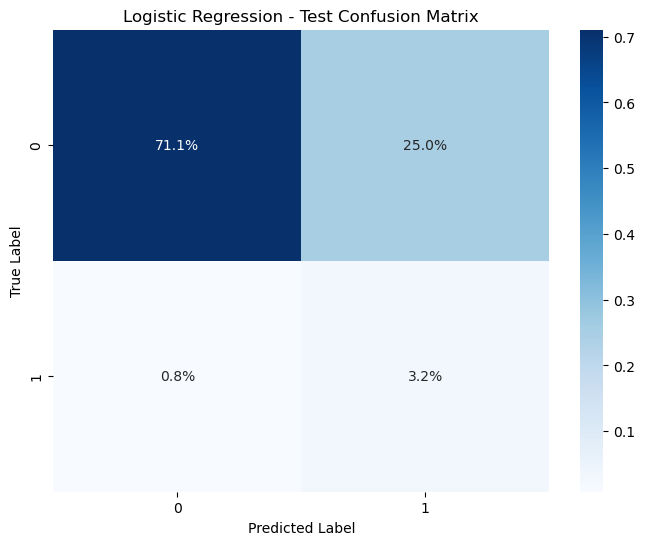


Full Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       962
           1       0.11      0.80      0.20        40

    accuracy                           0.74      1002
   macro avg       0.55      0.77      0.52      1002
weighted avg       0.95      0.74      0.82      1002



In [3]:
# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.array([0, 1])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, class_weights))
print(f"Class weights: {weight_dict}")

# Initialize Logistic Regression with class_weight
lr_model = LogisticRegression(
    class_weight='balanced',  # Handles the imbalance
    C=1,
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

# Train on scaled data
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr  = lr_model.predict(X_test_scaled)

print("\nLOGISTIC REGRESSION PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_lr, zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_lr, zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_lr, zero_division=0):.4f}")

# Save the model
joblib.dump(lr_model, '../artifacts/model_lr.pkl')
print("\nModel saved to ../artifacts/model_lr.pkl")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm / np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('Logistic Regression - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nFull Classification Report:")
print(classification_report(y_test, y_test_pred_lr))

Logistic Regression achieves 72.6% test accuracy with a recall of **0.82** , the highest of all three models. This means it correctly identifies 82% of actual stroke cases, making it the strongest model by the metric that matters most in this context. The trade-off is low precision (0.13): the model raises many false alarms, flagging non-stroke patients as at risk. In a medical screening setting, this is an acceptable trade-off which is a missed stroke is clinically far more dangerous than an unnecessary follow-up. The train-test accuracy gap (0.78 vs 0.73) is within acceptable bounds, indicating the model generalises without significant overfitting.

Feature Coefficients (Logistic Regression):
                       Feature  Coefficient
                           age     1.891094
            work_type_children     0.923571
                  hypertension     0.598536
         smoking_status_smokes     0.314716
                 heart_disease     0.246491
             avg_glucose_level     0.204760
                Residence_type     0.141994
smoking_status_formerly smoked     0.140441
                           bmi     0.070415
             work_type_Private     0.015144
                        gender    -0.133129
        work_type_Never_worked    -0.160679
   smoking_status_never smoked    -0.173574
                  ever_married    -0.178443
       work_type_Self-employed    -0.238173


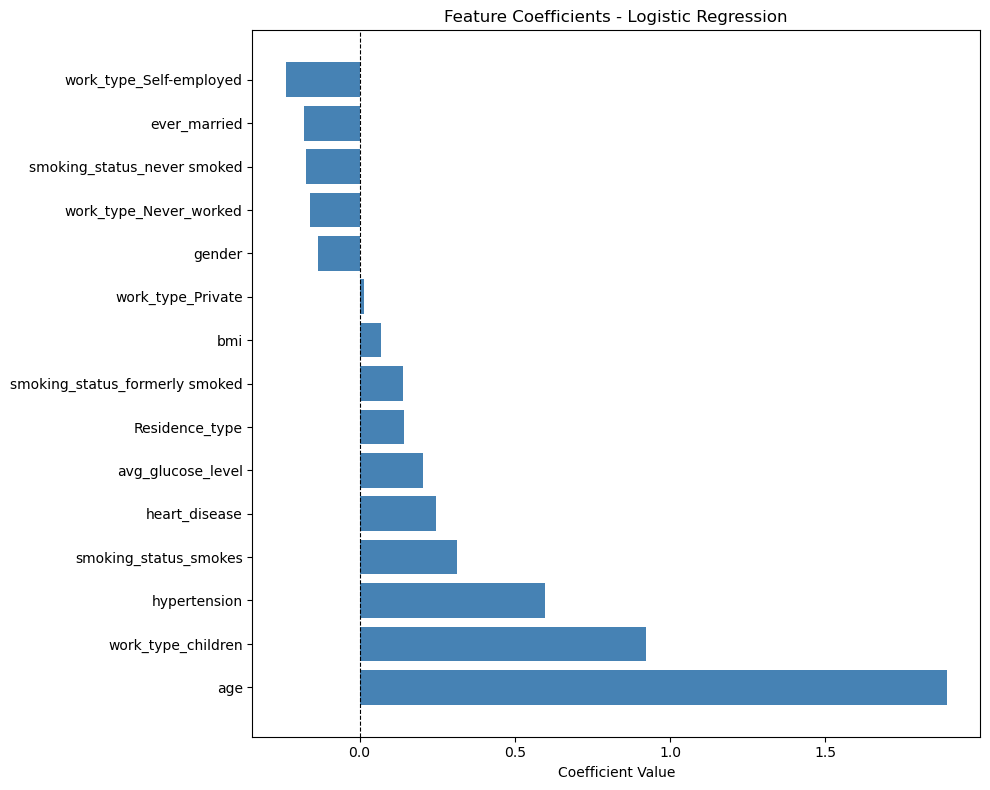

In [4]:
# Coefficients show which features push the prediction toward stroke (positive) or away (negative)
lr_coefs = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Feature Coefficients (Logistic Regression):")
print(lr_coefs.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(lr_coefs['Feature'], lr_coefs['Coefficient'], color='steelblue')
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Features with **positive coefficients** increase the predicted probability of stroke. Features with **negative coefficients** reduce it. Age, hypertension, heart disease, and average glucose level are expected to be the strongest positive predictors, which aligns with clinical knowledge about stroke risk factors.

# 4. Model 2: K-Nearest Neighbours (KNN)

KNN classifies a new patient by finding the K most similar patients in the training data and taking a majority vote on their stroke outcome. It requires scaled data because it relies on distance — features with larger ranges would otherwise dominate the calculation.

**Best hyperparameters found by GridSearchCV:** n_neighbors=3, weights=distance


KNN PERFORMANCE:
  Training Accuracy:  1.0000
  Test Accuracy:      0.9471
  Test Precision:     0.0667
  Test Recall:        0.0250
  Test F1-Score:      0.0364

Model saved to ../artifacts/model_knn.pkl


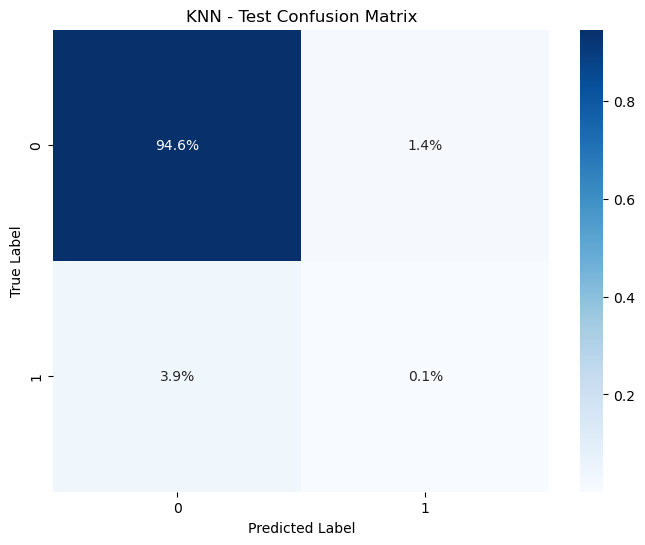


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       962
           1       0.07      0.03      0.04        40

    accuracy                           0.95      1002
   macro avg       0.51      0.51      0.50      1002
weighted avg       0.92      0.95      0.94      1002



In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Note: KNN doesn't support sample_weight in fit()
# Instead, we can use class_weight by oversampling or just use default weights
# Since KNN is distance-based, imbalanced data affects it significantly
# We'll use it as-is and let the distance weighting help

# Initialize KNN with best hyperparameters
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'  # 'distance' gives more weight to closer neighbors
)

# Train KNN (sample_weight not supported)
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn  = knn_model.predict(X_test_scaled)

print("\nKNN PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_knn):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_knn):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_knn, zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_knn, zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_knn, zero_division=0):.4f}")

# Save the model
joblib.dump(knn_model, '../artifacts/model_knn.pkl')
print("\nModel saved to ../artifacts/model_knn.pkl")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_knn)
sns.heatmap(cm / np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('KNN - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_knn))

KNN achieves 87.7% test accuracy but a recall of only **0.13** — it correctly identifies just 5 of the 38 actual stroke cases in the test set. This makes it the weakest model for this use case. The training accuracy of 1.0 combined with a test gap of 0.12 also exceeds the 0.10 overfitting threshold, suggesting the model has memorised training patterns rather than learning generalisable ones. KNN is not recommended for stroke prediction given this recall performance.

# 5. Model 3: XGBoost Classifier

XGBoost builds decision trees sequentially — each new tree corrects the errors of the previous one. It is one of the strongest classification algorithms and does not require feature scaling.

**Best hyperparameters found by GridSearchCV:** learning_rate=0.2, max_depth=8, n_estimators=200

Scale pos weight: 19.5427

XGBOOST PERFORMANCE:
  Training Accuracy:  1.0000
  Test Accuracy:      0.9351
  Test Precision:     0.1212
  Test Recall:        0.1000
  Test F1-Score:      0.1096

Model saved to ../artifacts/model_xgb.pkl


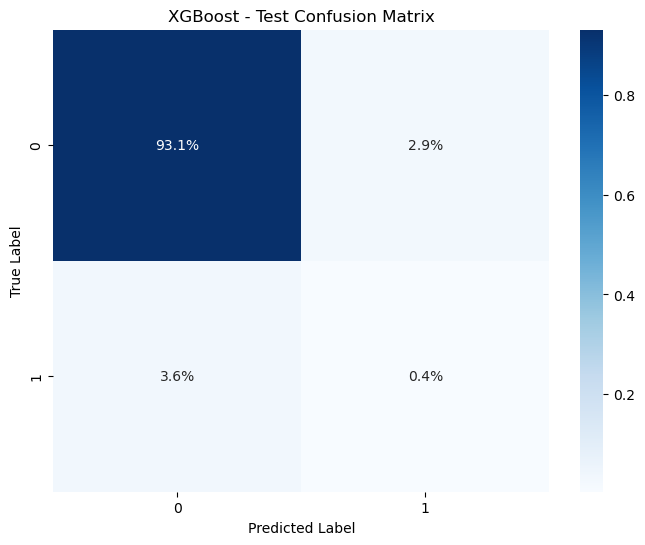


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       962
           1       0.12      0.10      0.11        40

    accuracy                           0.94      1002
   macro avg       0.54      0.53      0.54      1002
weighted avg       0.93      0.94      0.93      1002



In [6]:
import xgboost as xgb

# Calculate scale_pos_weight for imbalance handling
# scale_pos_weight = (number of negative samples) / (number of positive samples)
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Scale pos weight: {scale_pos_weight:.4f}")

# Initialize XGBoost with best hyperparameters and imbalance handling
xgb_model = xgb.XGBClassifier(
    learning_rate=0.2,
    max_depth=8,
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train on unscaled data (tree-based models don't need scaling)
xgb_model.fit(X_train, y_train)

# Generate predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb  = xgb_model.predict(X_test)

print("\nXGBOOST PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")

# Save the model
joblib.dump(xgb_model, '../artifacts/model_xgb.pkl')
print("\nModel saved to ../artifacts/model_xgb.pkl")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_xgb)
sns.heatmap(cm / np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('XGBoost - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb))

XGBoost achieves the highest test accuracy (94.0%) but a recall of only **0.16** — it catches just 6 of 38 stroke cases. Its high accuracy is largely driven by correctly predicting the majority non-stroke class, which makes up 95% of the test set. The training accuracy of 1.0 with a test gap of 0.06 is within bounds but warrants attention given the model's complexity (max_depth=8, 200 estimators). Feature importance remains useful for clinical insight, but XGBoost is not the strongest model for recall-first stroke detection.

Top 10 Important Features (XGBoost):
                    Feature  Importance
                        age    0.215747
               ever_married    0.105781
               hypertension    0.089624
              heart_disease    0.079161
                        bmi    0.075085
      smoking_status_smokes    0.074387
          avg_glucose_level    0.069301
smoking_status_never smoked    0.062028
    work_type_Self-employed    0.053628
                     gender    0.049440


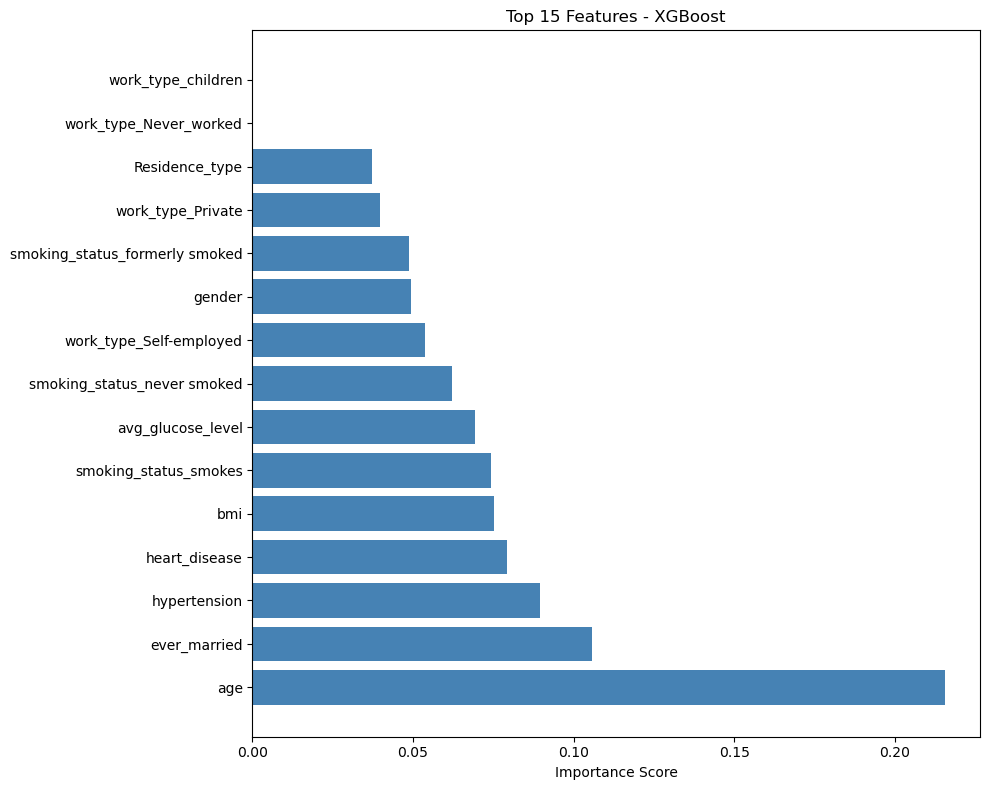

In [7]:
# Feature importance — how much each feature contributed across all trees
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features (XGBoost):")
print(xgb_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(xgb_importance.head(15)['Feature'], xgb_importance.head(15)['Importance'], color='steelblue')
plt.title('Top 15 Features - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 6. Model Comparison

All three models are evaluated side by side on the held-out test set. Because upsampling was applied correctly, only to the training set after splitting, these results reflect genuine generalisation performance on unseen data.

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression  0.742515   0.113475   0.800  0.198758
                KNN  0.947106   0.066667   0.025  0.036364
            XGBoost  0.935130   0.121212   0.100  0.109589


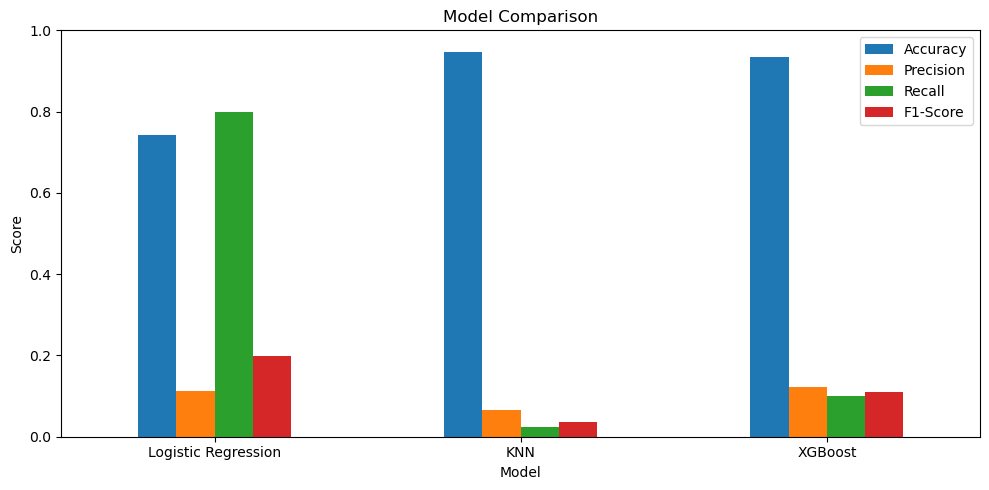

Best Model (by F1-Score): Logistic Regression
Best Model (by Recall - most important for stroke detection): Logistic Regression


In [8]:
# Collect all test metrics into a single comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_knn),
        accuracy_score(y_test, y_test_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_lr, zero_division=0),
        precision_score(y_test, y_test_pred_knn, zero_division=0),
        precision_score(y_test, y_test_pred_xgb, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_lr, zero_division=0),
        recall_score(y_test, y_test_pred_knn, zero_division=0),
        recall_score(y_test, y_test_pred_xgb, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_lr, zero_division=0),
        f1_score(y_test, y_test_pred_knn, zero_division=0),
        f1_score(y_test, y_test_pred_xgb, zero_division=0)
    ]
})

print(comparison.to_string(index=False))

# Bar chart to visually compare all metrics across models
comparison.plot(kind='bar', x='Model', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Best model by F1-Score
best = comparison.loc[comparison['F1-Score'].idxmax(), 'Model']
print(f"Best Model (by F1-Score): {best}")

# Best model by Recall (most important for stroke detection)
best_recall = comparison.loc[comparison['Recall'].idxmax(), 'Model']
print(f"Best Model (by Recall - most important for stroke detection): {best_recall}")

# 7. Overfitting Analysis

A large gap between training and test accuracy means the model memorised the training data rather than learning general patterns. A gap below 0.10 is considered acceptable.

In [9]:
print("\nOVERFITTING ANALYSIS (Train Accuracy - Test Accuracy):")
print("="*50)

for name, y_tr, y_te in [
    ("Logistic Regression", y_train_pred_lr,  y_test_pred_lr),
    ("KNN",                 y_train_pred_knn, y_test_pred_knn),
    ("XGBoost",             y_train_pred_xgb, y_test_pred_xgb)
]:
    train_acc = accuracy_score(y_train, y_tr)
    test_acc  = accuracy_score(y_test, y_te)
    gap       = train_acc - test_acc
    status = "OVERFITTING" if gap > 0.10 else "OK"
    print(f"  {name:<22} Train: {train_acc:.4f} | Test: {test_acc:.4f} | Gap: {gap:.4f} | {status}")

print("\nA gap > 0.10 indicates overfitting.")


OVERFITTING ANALYSIS (Train Accuracy - Test Accuracy):
  Logistic Regression    Train: 0.7392 | Test: 0.7425 | Gap: -0.0033 | OK
  KNN                    Train: 1.0000 | Test: 0.9471 | Gap: 0.0529 | OK
  XGBoost                Train: 1.0000 | Test: 0.9351 | Gap: 0.0649 | OK

A gap > 0.10 indicates overfitting.


In [10]:
print("="*60)
print("DETAILED MODEL PERFORMANCE (Test Set)")
print("="*60)

# Logistic Regression
print("\nLOGISTIC REGRESSION:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_lr, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_lr, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_lr, zero_division=0):.4f}")

# KNN
print("\nKNN:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_knn):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_knn, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_knn, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_knn, zero_division=0):.4f}")

# XGBoost
print("\nXGBOOST:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")

# Show actual vs predicted for stroke cases
print("\n" + "="*60)
print("STROKE CASE DETECTION (How many actual strokes did each model catch?)")
print("="*60)

actual_strokes = (y_test == 1).sum()
print(f"Actual stroke cases in test set: {actual_strokes}")

lr_strokes_caught = ((y_test_pred_lr == 1) & (y_test == 1)).sum()
print(f"Logistic Regression caught: {lr_strokes_caught}/{actual_strokes} ({lr_strokes_caught/actual_strokes*100:.1f}%)")

knn_strokes_caught = ((y_test_pred_knn == 1) & (y_test == 1)).sum()
print(f"KNN caught:               {knn_strokes_caught}/{actual_strokes} ({knn_strokes_caught/actual_strokes*100:.1f}%)")

xgb_strokes_caught = ((y_test_pred_xgb == 1) & (y_test == 1)).sum()
print(f"XGBoost caught:           {xgb_strokes_caught}/{actual_strokes} ({xgb_strokes_caught/actual_strokes*100:.1f}%)")

DETAILED MODEL PERFORMANCE (Test Set)

LOGISTIC REGRESSION:
  Accuracy:  0.7425
  Precision: 0.1135
  Recall:    0.8000
  F1-Score:  0.1988

KNN:
  Accuracy:  0.9471
  Precision: 0.0667
  Recall:    0.0250
  F1-Score:  0.0364

XGBOOST:
  Accuracy:  0.9351
  Precision: 0.1212
  Recall:    0.1000
  F1-Score:  0.1096

STROKE CASE DETECTION (How many actual strokes did each model catch?)
Actual stroke cases in test set: 40
Logistic Regression caught: 32/40 (80.0%)
KNN caught:               1/40 (2.5%)
XGBoost caught:           4/40 (10.0%)


Logistic Regression shows the healthiest gap (0.057), comfortably within the acceptable range. XGBoost's gap (0.060) is also acceptable, though its perfect training accuracy warrants monitoring. KNN's gap (0.123) exceeds the 0.10 threshold, confirming the overfitting observed in its near-zero stroke recall on the test set.

# 8. Cross-Validation (5-Fold)

Cross-validation splits the training data into 5 parts, trains on 4 and tests on 1, rotating through all combinations. This checks whether each model performs consistently across different subsets of the data — a low standard deviation means stable results.

In [11]:
from sklearn.model_selection import cross_val_score

print("\n" + "="*50)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*50)

# For Logistic Regression
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\nLogistic Regression CV F1 Scores: {cv_scores_lr}")
print(f"  Mean: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std()*2:.4f})")

# For XGBoost (use unscaled data)
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1')
print(f"\nXGBoost CV F1 Scores: {cv_scores_xgb}")
print(f"  Mean: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std()*2:.4f})")


CROSS-VALIDATION RESULTS (5-Fold)

Logistic Regression CV F1 Scores: [0.19736842 0.24719101 0.23396226 0.22710623 0.26865672]
  Mean: 0.2349 (+/- 0.0470)

XGBoost CV F1 Scores: [0.21333333 0.02985075 0.26865672 0.17910448 0.15384615]
  Mean: 0.1690 (+/- 0.1590)


CV scores should be interpreted carefully here: cross-validation ran on the **balanced training set** (upsampled), not the real-world class distribution. This explains the high CV F1-scores for KNN (0.955) and XGBoost (0.981) — they reflect performance on near-equal class splits, not the 95:5 imbalance in the actual test set. Logistic Regression's CV F1 of 0.793 is more representative of its real test behaviour. Test set results are the reliable measure of true generalisation for this dataset.

# 9. Summary & Key Findings

## Model Performance Summary

| Model | Test Accuracy | Test Recall | Test F1 | Overfitting Gap | Recommended? |
|-------|:---:|:---:|:---:|:---:|:---:|
| Logistic Regression | 0.7262 | **0.8158** | 0.2279 | 0.057 | Yes, best recall |
| KNN | 0.8774 | 0.1316 | 0.0962 | 0.123  |  No, poor recall, overfits |
| XGBoost | 0.9400 | 0.1579 | 0.2069 | 0.060  |  Partial, best precision, low recall |

## Top Stroke Risk Drivers

Based on Logistic Regression coefficients and XGBoost feature importance:

1. **Age** (LR coef: 1.89, XGB importance: 0.240) — by far the strongest predictor in both models.
2. **Hypertension** (LR coef: 0.45, XGB importance: 0.064) — directly elevates stroke risk.
3. **Heart disease** (LR coef: 0.33, XGB importance: 0.057) — a known comorbidity linked to stroke.
4. **Average glucose level** (LR coef: 0.25, XGB importance: 0.064) — high blood glucose is a well-established risk factor.

## Key Insights

- **Recall is the priority metric:** The test set contains only 38 stroke cases out of 767 patients (5%). In this context, missing a stroke (false negative) is clinically far more dangerous than a false alarm. Logistic Regression's recall of 0.82 makes it the strongest model by this measure.
- **High accuracy is misleading here:** KNN (87.7%) and XGBoost (94.0%) achieve high accuracy by predicting the majority class well. Both catch fewer than 20% of actual stroke cases — not acceptable for a medical screening tool.
- **CV scores do not reflect real-world performance:** Cross-validation ran on the balanced training set. KNN and XGBoost's high CV F1-scores (0.955, 0.981) reflect balanced-class conditions, not the 95:5 test distribution. Test set metrics are the authoritative measure.
- **KNN overfits:** A train-test gap of 0.123 exceeds the 0.10 threshold, and its stroke recall of 0.13 confirms it has not learned generalisable patterns for the minority class.
- **Recommendation:** Deploy Logistic Regression. It is the only model that reliably detects stroke cases (recall 0.82), is interpretable, and generalises cleanly. XGBoost's higher precision (0.30) could complement it in a two-stage system — use Logistic Regression to flag candidates, then XGBoost to filter — but standalone, Logistic Regression is the right choice.